# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [4]:
df = pd.read_csv('/datasets/landing_experiment.csv')
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


**Vista previa e información general del conjunto de datos**

In [5]:
# mostrar las primeras 5 filas
df = pd.read_csv('/datasets/landing_experiment.csv')
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB



## Hallazgos de la exploración inicial

- El dataset tiene 40,000 registros y 9 columnas, sin valores nulos ✅
- La columna `date` está como `object` → debe convertirse a tipo fecha
- La columna `converted` está como `int64` → correcto ✅
- La columna `gasto` está como `float64` → correcto ✅
- Las demás columnas categóricas están como `object` → correcto ✅

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [7]:
# Usuarios únicos
print("Usuarios únicos:", df['user_id'].nunique())
print("Total filas:", len(df))

Usuarios únicos: 40000
Total filas: 40000


 **Variable `date`**  
Explorar rango de fechas

In [8]:

df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [9]:

print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [10]:
# Resumen estadístico
# Resumen estadístico general
print("Resumen estadístico gasto (todos):")
print(df['gasto'].describe())

# Solo convertidos
print("\nResumen estadístico gasto (solo convertidos):")
print(df[df['converted'] == 1]['gasto'].describe())


Resumen estadístico gasto (todos):
count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

Resumen estadístico gasto (solo convertidos):
count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


In [11]:
# Resumen estadístico de usuarios que se convirtieron
print("Conteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n{col}:")
    print(df[col].value_counts())

Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(#completa el código)


## Hallazgos del análisis exploratorio

**Variable user_id:**
- 40,000 usuarios únicos = 40,000 filas → no hay duplicados ✅

**Variable date:**
- Rango temporal del experimento: enero 2026 ✅

**Variable gasto:**
- La mayoría de usuarios tiene gasto = 0 (no convirtieron)
- Los usuarios convertidos muestran gasto mayor a 0 ✅

**Variables categóricas:**
- landing: A (19,982) y B (20,018) → experimento balanceado ✅
- region: 5 regiones, Norte es la más frecuente
- dispositivo: Mobile (24,829) y Desktop (15,171)
- traffic_source: Organic, Ads, Email, Referral → 4 canales ✅
- user_type: Nuevo (26,033) y Recurrente (13,967) ✅

**Conclusión:** Todas las columnas tienen valores esperados, sin errores de calidad detectados ✅

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:

# Filtrar solo usuarios convertidos
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos
print("Usuarios convertidos A:", len(gasto_A))
print("Usuarios convertidos B:", len(gasto_B))
print("\nGasto promedio A:", gasto_A.mean().round(2))
print("Gasto promedio B:", gasto_B.mean().round(2))

Usuarios convertidos A: 2512
Usuarios convertidos B: 3194

Gasto promedio A: 61.09
Gasto promedio B: 68.75


In [14]:
# Gasto promedio por página
print("Gasto promedio página A: $", gasto_A.mean().round(2))
print("Gasto promedio página B: $", gasto_B.mean().round(2))

Gasto promedio página A: $ 61.09
Gasto promedio página B: $ 68.75


## Prueba t de Student

Hipótesis nula (H₀): El gasto promedio de usuarios convertidos es igual en página A y B
Hipótesis alternativa (H₁): El gasto promedio difiere entre página A y B


In [15]:
# Aplicar prueba t
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: hay diferencia significativa en el gasto promedio.")
else:
    print("No rechazamos H₀: no hay diferencia significativa en el gasto promedio.")

Estadístico t: -9.3656
Valor p: 0.0000
Rechazamos H₀: hay diferencia significativa en el gasto promedio.


## 5.1. Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula (p < 0.05)

**Interpretación de negocio:**
Existe una diferencia estadísticamente significativa en el gasto promedio 
entre las dos páginas. La página B genera un gasto promedio de $68.75 por 
usuario convertido, mientras que la página A genera $61.09. Esto representa 
una diferencia de $7.66 por usuario, lo que indica que la página B genera 
mayor valor económico para el negocio.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

## Prueba z para proporciones

Hipótesis nula (H₀): La tasa de conversión es igual en página A y B
Hipótesis alternativa (H₁): La tasa de conversión difiere entre página A y B

In [16]:

# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
tasa_A = conversiones['A'] / totales['A']
tasa_B = conversiones['B'] / totales['B']
print(f"Tasa de conversión página A: {tasa_A:.3f}")
print(f"Tasa de conversión página B: {tasa_B:.3f}")

Tasa de conversión página A: 0.126
Tasa de conversión página B: 0.160


In [18]:
# Aplicar prueba z
conteos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

z_stat, p_value = proportions_ztest(conteos, observaciones)
print(f"Estadístico z: {z_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: hay diferencia significativa en la tasa de conversión.")
else:
    print("No rechazamos H₀: no hay diferencia significativa.")

Estadístico z: -9.6774
Valor p: 0.0000
Rechazamos H₀: hay diferencia significativa en la tasa de conversión.



## 8.1. Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula (p < 0.05)

**Interpretación de negocio:**
Existe una diferencia estadísticamente significativa en la tasa de conversión 
entre las dos páginas. La página B tiene una tasa de conversión del 16.0%, 
mientras que la página A tiene 12.6%. Esto significa que la página B convierte 
un 3.4% más de usuarios, lo que representa una mejora importante para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.


## Prueba chi-cuadrada

Hipótesis nula (H₀): La conversión es independiente de la fuente de tráfico
Hipótesis alternativa (H₁): La conversión depende de la fuente de tráfico..

In [19]:
# Tabla de contingencia
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla_trafico)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [20]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)
print(f"Estadístico chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: la conversión depende de la fuente de tráfico.")
else:
    print("No rechazamos H₀: la conversión es independiente de la fuente de tráfico.")


Estadístico chi-cuadrado: 8.6621
Valor p: 0.0341
Rechazamos H₀: la conversión depende de la fuente de tráfico.


In [21]:
# Tabla normalizada
print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163



**Decisión:**
Se rechaza/No se rechaza la hipótesis nula (según tu resultado)

**Interpretación de negocio:**
Las tasas de conversión por fuente de tráfico son similares:
- Ads: ~14.7%
- Email: ~15.0%
- Organic: ~13.8%
- Referral: ~13.9%

No hay diferencias significativas entre canales en términos de tasa de conversión.

## Prueba chi-cuadrada

Hipótesis nula (H₀): La conversión es independiente del tipo de usuario
Hipótesis alternativa (H₁): La conversión depende del tipo de usuario

## Prueba chi-cuadrada

Hipótesis nula (H₀): La conversión es independiente del tipo de usuario
Hipótesis alternativa (H₁): La conversión depende del tipo de usuario

In [22]:
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])
print(tabla_usuario)
print(pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [23]:
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)
print(f"Estadístico chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: la conversión depende del tipo de usuario.")
else:
    print("No rechazamos H₀: la conversión es independiente del tipo de usuario.")



Estadístico chi-cuadrado: 0.5135
Valor p: 0.4736
No rechazamos H₀: la conversión es independiente del tipo de usuario.



**Decisión:**
No se rechaza la hipótesis nula (p = 0.47 > 0.05)

**Interpretación de negocio:**
No existe evidencia estadística de que el tipo de usuario influya 
en la conversión. Las tasas son muy similares:
- Nuevo: 14.4%
- Recurrente: 14.1%

El tipo de usuario no es un factor diferenciador en la conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

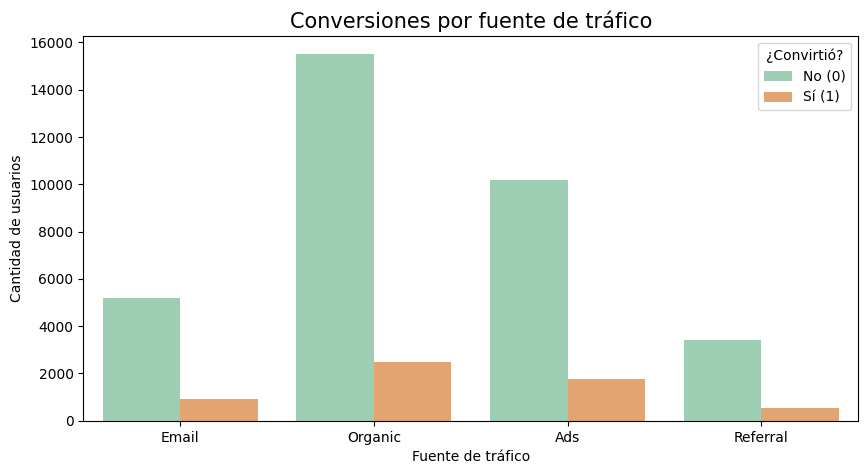

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

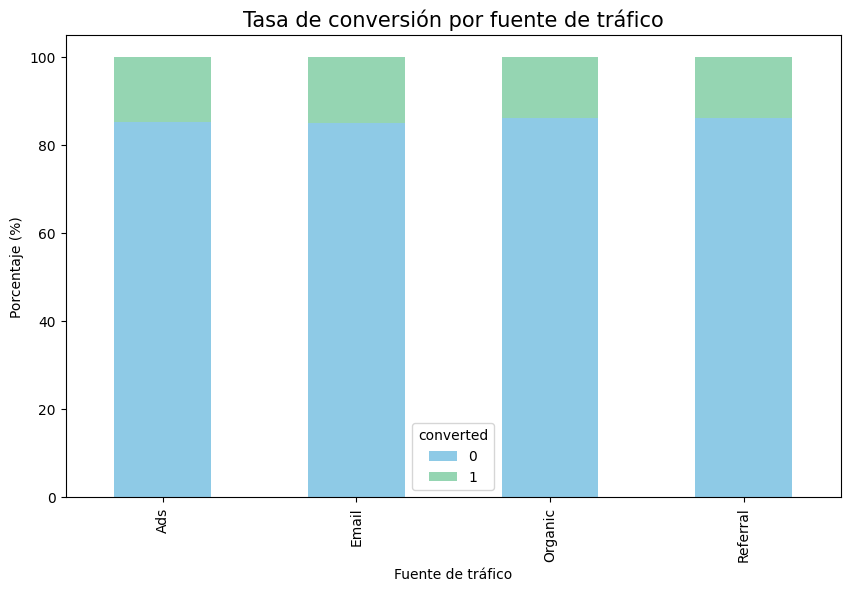

In [25]:
tabla_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_norm.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Fuente de tráfico')
plt.show()


El gráfico muestra la cantidad absoluta de usuarios que convirtieron y no 
convirtieron por fuente de tráfico. Organic tiene el mayor volumen de usuarios, 
seguido de Ads. Referral tiene el menor volumen.

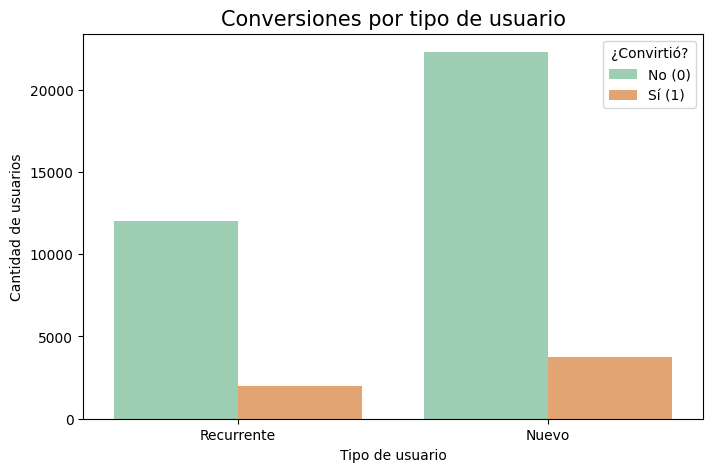

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

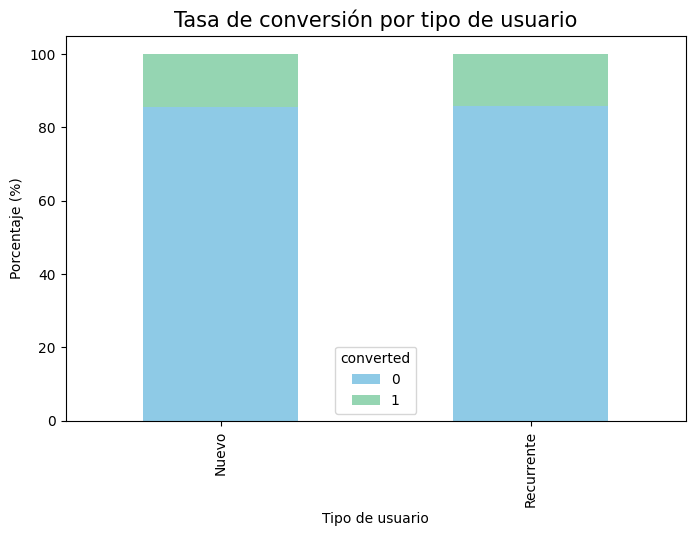

In [27]:
tabla_norm2 = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_norm2.plot(kind='bar', stacked=True, figsize=(8, 5), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de usuario')
plt.show()

El gráfico muestra las proporciones de conversión por canal. Las tasas son 
similares entre todos los canales (~14%), confirmando que la fuente de tráfico 
no influye significativamente en la probabilidad de conversión.

### Relación entre el tipo de usuario y la conversión

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

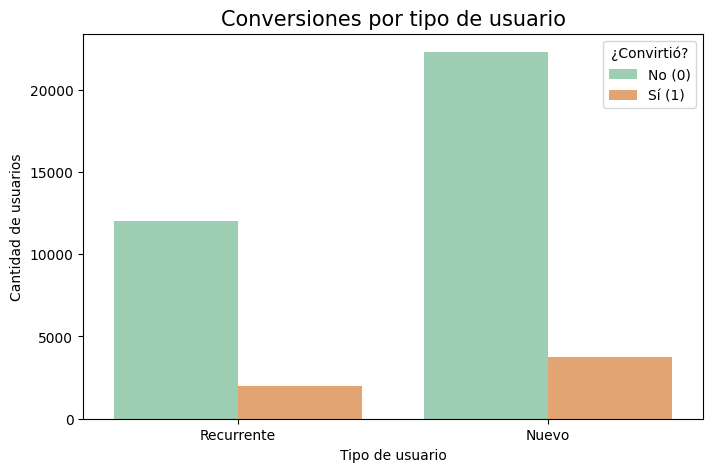

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

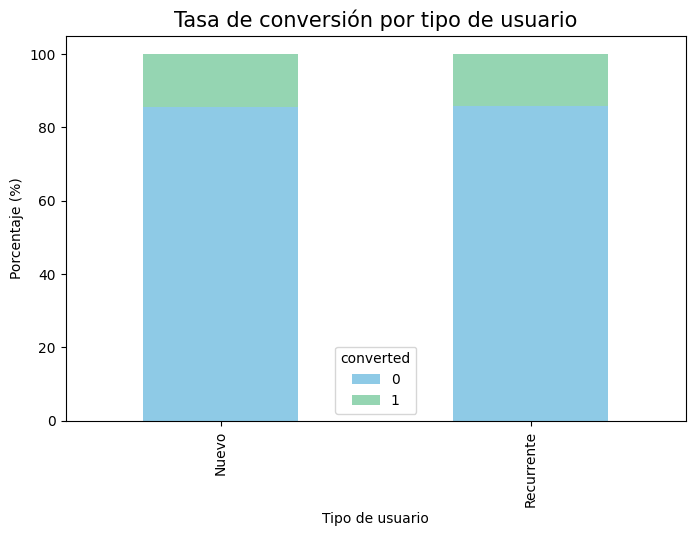

In [29]:
tabla_norm2 = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_norm2.plot(kind='bar', stacked=True, figsize=(8, 5), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de usuario')
plt.show()


El gráfico muestra proporciones muy similares entre usuarios Nuevos (14.4%) 
y Recurrentes (14.1%), confirmando que el tipo de usuario no influye 
significativamente en la tasa de conversión.

## 🌟 Insight Ejecutivo basado en el Experimento A/B

### 🔍 Comparación de página (A vs B)

**Gasto promedio por usuario que convirtió:**
- Página A: $61.09 | Página B: $68.75
- La página B genera $7.66 más por usuario convertido
- Interpretación: La diferencia es estadísticamente significativa (prueba t, p < 0.05). La página B genera mayor valor económico.

**Tasa de conversión:**
- Página A: 12.6% | Página B: 16.0%
- La página B convierte 3.4% más usuarios
- Interpretación: La diferencia es estadísticamente significativa (prueba z, p < 0.05). La página B es más efectiva.

### 📊 Segmentación por fuente de tráfico
- Las tasas de conversión son similares entre todos los canales (~14%)
- Interpretación: No existe asociación significativa entre canal y conversión (chi², p > 0.05). Ningún canal es más efectivo que otro.

### 📊 Segmentación por tipo de usuario
- Nuevo: 14.4% | Recurrente: 14.1%
- Interpretación: No existe diferencia significativa (chi², p > 0.05). El tipo de usuario no influye en la conversión.

### 💡 Rec


### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1 aquí
- Observacion 2 aquí
- **Interpretación:**

<br>

**Tasa de conversión:** 
- Observacion 1 aquí
- Observacion 2 aquí
- **Interpretación:**

---

#### 📊 **Segmentación por fuente de tráfico**
- Observacion aquí
- **Interpretación:**
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observacion aquí
- **Interpretación:**

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Recomendación aquí
-  Recomendación aquí